In [3]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn import set_config 
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [8]:
df = pd.read_csv("web_Anomaly_train.csv")

In [9]:
df

,throughput,congestion,packet_loss,latency,jitter,isRouterV6,Planned route,Percentage video occupancy,Bitrate video,Number videos,anomaly
0,2.29,11.31,0.0,7.65,0.88,1,1,10,167,2,0
1,0.65,57.27,7.5,10.86,0.84,0,0,10,167,4,0
2,2.35,19.63,15.0,9.53,0.87,0,0,20,334,1,0
3,0.48,35.91,0.0,9.67,0.79,0,0,10,167,1,0
4,1.62,4.78,0.0,5.04,0.85,1,1,10,167,2,0
...,...,...,...,...,...,...,...,...,...,...,...
695,2.51,6.98,0.0,9.49,1.00,0,0,10,167,1,0
696,0.37,69.20,2.5,5.73,8.17,1,1,80,1336,1,0
697,1.52,0.09,0.0,10.81,0.58,0,0,0,0,0,0
698,2.78,54.68,35.0,5.38,1.71,1,1,120,2004,1,1


In [10]:
df["video_Load"] = ( df["Percentage video occupancy"]*df["Bitrate video"]*df["Number videos"])

In [11]:
x_train = df.drop(["anomaly","Percentage video occupancy","Bitrate video","Number videos"],axis=1)
y_train = df['anomaly']

In [12]:
x_train

,throughput,congestion,packet_loss,latency,jitter,isRouterV6,Planned route,video_Load
0,2.29,11.31,0.0,7.65,0.88,1,1,3340
1,0.65,57.27,7.5,10.86,0.84,0,0,6680
2,2.35,19.63,15.0,9.53,0.87,0,0,6680
3,0.48,35.91,0.0,9.67,0.79,0,0,1670
4,1.62,4.78,0.0,5.04,0.85,1,1,3340
...,...,...,...,...,...,...,...,...
695,2.51,6.98,0.0,9.49,1.00,0,0,1670
696,0.37,69.20,2.5,5.73,8.17,1,1,106880
697,1.52,0.09,0.0,10.81,0.58,0,0,0
698,2.78,54.68,35.0,5.38,1.71,1,1,240480


In [15]:
y_train=pd.DataFrame(y_train,columns=["anomaly"])

In [16]:
y_train

,anomaly
0,0
1,0
2,0
3,0
4,0
...,...
695,0
696,0
697,0
698,1


In [17]:
another_df = pd.read_csv("web_Anomaly_test.csv")

In [73]:
another_df

,throughput,congestion,packet_loss,latency,jitter,isRouterV6,Planned route,Percentage video occupancy,Bitrate video,Number videos,anomaly
0,2.66,0.07,0.0,8.12,0.49,1,1,0,0,0,0
1,0.78,115.37,20.0,10.00,1.47,0,0,100,1670,1,1
2,2.57,0.08,0.0,10.76,0.53,0,0,0,0,0,0
3,2.27,0.08,17.5,10.15,0.88,0,0,80,1336,2,0
4,0.99,20.82,0.0,6.99,0.43,1,1,20,334,2,0
...,...,...,...,...,...,...,...,...,...,...,...
296,2.37,0.57,0.0,7.56,0.57,1,1,0,0,0,0
297,0.30,79.21,2.5,5.59,0.91,1,1,80,1336,1,0
298,1.67,19.79,10.0,12.29,1.15,0,0,20,334,2,0
299,1.77,19.35,0.0,4.86,0.57,1,1,20,334,2,0


In [74]:
another_df["video_Load"] = ( another_df["Percentage video occupancy"]*another_df["Bitrate video"]*another_df["Number videos"])

In [104]:
x_test = another_df.drop(["anomaly","Percentage video occupancy","Bitrate video","Number videos"],axis=1)
y_test = another_df["anomaly"]

In [105]:
x_test

,throughput,congestion,packet_loss,latency,jitter,isRouterV6,Planned route,video_Load
0,2.66,0.07,0.0,8.12,0.49,1,1,0
1,0.78,115.37,20.0,10.00,1.47,0,0,167000
2,2.57,0.08,0.0,10.76,0.53,0,0,0
3,2.27,0.08,17.5,10.15,0.88,0,0,213760
4,0.99,20.82,0.0,6.99,0.43,1,1,13360
...,...,...,...,...,...,...,...,...
296,2.37,0.57,0.0,7.56,0.57,1,1,0
297,0.30,79.21,2.5,5.59,0.91,1,1,106880
298,1.67,19.79,10.0,12.29,1.15,0,0,13360
299,1.77,19.35,0.0,4.86,0.57,1,1,13360


In [102]:
# y_test = pd.DataFrame(y_test,columns=["anomaly"])

In [106]:
y_test

0      0
1      1
2      0
3      0
4      0
      ..
296    0
297    0
298    0
299    0
300    0
Name: anomaly, Length: 301, dtype: int64

<Axes: >

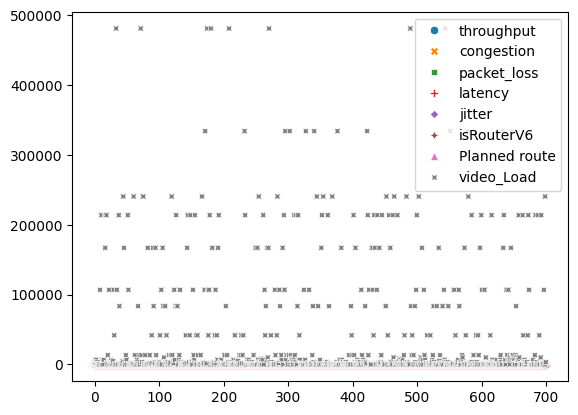

In [85]:
sns.scatterplot(x_train)

/var/folders/cr/whp0vvwn42l87b_1wbx9kl200000gn/T/ipykernel_2158/10025218.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train)


<Axes: ylabel='Density'>

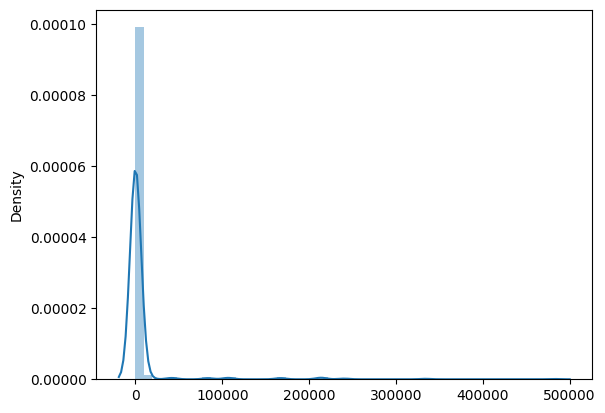

In [86]:
sns.distplot(x_train)

# Model Training

In [23]:
trf1 = IsolationForest()

In [24]:
pipe = Pipeline([('trf1',trf1)])

In [109]:
pipe.fit(x_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('trf1', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [110]:
pipe.named_steps

{'trf1': IsolationForest()}

In [111]:
y_pred = pipe.predict(x_test)

In [112]:
y_pred

array([ 1, -1,  1, -1,  1, -1, -1,  1,  1, -1, -1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1, -1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1, -1,  1,  1, -1,  1,  1, -1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1, -1, -1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1,
        1,  1,  1,  1, -1,  1, -1, -1, -1,  1, -1, -1,  1, -1,  1,  1,  1,
       -1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1, -1,  1, -1, -1, -1,  1,  1,  1, -1,  1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1, -1,  1,
       -1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1,  1, -1,
        1,  1, -1,  1,  1,  1, -1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1

In [117]:
y_pred_fixed = np.where(y_pred == -1, 1, 0)

In [118]:
y_pred_fixed

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [120]:
print(f"The Accuracy is :{accuracy_score(y_test,y_pred_fixed)*100}")

The Accuracy is :85.04983388704319


In [131]:
# score1 = cross_val_score(pipe, x_train, y_train, cv=10, scoring='accuracy').mean()

In [132]:
# score1

np.float64(0.0014285714285714286)

In [137]:
# score2 = cross_val_score(pipe, x_train, y_train, cv=5, scoring='roc_auc').mean()

In [138]:
# score2

np.float64(0.03377895809893318)

In [139]:
import pickle
pickle.dump(pipe,open('pipe_anomaly_Detection.pkl','wb'))

# Try Different Way 

## Type 2 :

In [109]:
df2 = pd.read_csv("web_Anomaly_train.csv")

In [110]:
x_train2 = df2.drop(["anomaly","Percentage video occupancy","Bitrate video","Number videos"],axis=1)
y_train2 = df2['anomaly']

In [111]:
y_train2=pd.DataFrame(y_train2,columns=["anomaly"])

In [112]:
another_df2 = pd.read_csv("web_Anomaly_test.csv")

In [113]:
x_test2 = another_df2.drop(["anomaly","Percentage video occupancy","Bitrate video","Number videos"],axis=1)
y_test2 = another_df2["anomaly"]

In [114]:
trf2 = IsolationForest()

In [115]:
pipe = Pipeline([('trf2',trf2)])

In [116]:
pipe.fit(x_train2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('trf2', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [117]:
y_pred2 = pipe.predict(x_test2)

In [118]:
y_pred2

array([ 1, -1,  1,  1,  1, -1, -1,  1,  1, -1, -1, -1,  1, -1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1, -1,  1,  1, -1,  1, -1, -1,  1,  1, -1, -1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
       -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,
        1,  1,  1, -1, -1,  1, -1, -1, -1,  1, -1, -1,  1, -1,  1,  1,  1,
       -1, -1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1, -1,  1, -1, -1, -1,  1,  1,  1, -1,  1, -1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1, -1,  1, -1,  1,
       -1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1,  1, -1,
        1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1

In [119]:
y_pred2_fixed = np.where(y_pred2 == -1, 1, 0)

In [120]:
print(f"The Accuracy is :{accuracy_score(y_test2,y_pred2_fixed)*100}")

The Accuracy is :84.38538205980066


In [121]:
import pickle
pickle.dump(pipe,open('pipe_anomaly_Detection2.pkl','wb'))

## Type 3:

In [122]:
df3 = pd.read_csv("web_Anomaly_train.csv")

In [123]:
df3["network_quality"] = (
    (1 - df3["packet_loss"]) +
    (1 / (df3["latency"] + 1)) +
    (1 / (df3["jitter"] + 1))
)

In [124]:
df3.head()

,throughput,congestion,packet_loss,latency,jitter,isRouterV6,Planned route,Percentage video occupancy,Bitrate video,Number videos,anomaly,network_quality
0,2.29,11.31,0.0,7.65,0.88,1,1,10,167,2,0,1.647522
1,0.65,57.27,7.5,10.86,0.84,0,0,10,167,4,0,-5.872205
2,2.35,19.63,15.0,9.53,0.87,0,0,20,334,1,0,-13.370274
3,0.48,35.91,0.0,9.67,0.79,0,0,10,167,1,0,1.652380
4,1.62,4.78,0.0,5.04,0.85,1,1,10,167,2,0,1.706103


In [125]:
x_train3 = df3.drop(["anomaly","Percentage video occupancy","Bitrate video","Number videos","packet_loss","latency","jitter"],axis=1)
y_train3 = df3['anomaly']

In [126]:
y_train3=pd.DataFrame(y_train3,columns=["anomaly"])

In [127]:
another_df3 = pd.read_csv("web_Anomaly_test.csv")

In [128]:
another_df3["network_quality"] = (
    (1 - another_df3["packet_loss"]) +
    (1 / (another_df3["latency"] + 1)) +
    (1 / (another_df3["jitter"] + 1))
)

In [129]:
another_df3.head()

,throughput,congestion,packet_loss,latency,jitter,isRouterV6,Planned route,Percentage video occupancy,Bitrate video,Number videos,anomaly,network_quality
0,2.66,0.07,0.0,8.12,0.49,1,1,0,0,0,0,1.780790
1,0.78,115.37,20.0,10.00,1.47,0,0,100,1670,1,1,-18.504233
2,2.57,0.08,0.0,10.76,0.53,0,0,0,0,0,0,1.738629
3,2.27,0.08,17.5,10.15,0.88,0,0,80,1336,2,0,-15.878399
4,0.99,20.82,0.0,6.99,0.43,1,1,20,334,2,0,1.824457


In [130]:
x_test3 = another_df3.drop(["anomaly","Percentage video occupancy","Bitrate video","Number videos","packet_loss","latency","jitter"],axis=1)
y_test3 = another_df3["anomaly"]

In [131]:
trf3 = IsolationForest()

In [132]:
pipe = Pipeline([('trf3',trf3)])

In [133]:
pipe.fit(x_train3)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('trf3', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [134]:
y_pred3 = pipe.predict(x_test3)

In [135]:
y_pred3

array([ 1, -1,  1, -1,  1, -1, -1,  1,  1, -1, -1, -1,  1, -1,  1,  1,  1,
        1, -1, -1, -1,  1,  1,  1, -1, -1,  1,  1,  1,  1, -1,  1,  1, -1,
        1,  1, -1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1, -1,  1, -1,
        1,  1, -1, -1, -1,  1, -1,  1, -1, -1,  1,  1, -1, -1,  1,  1,  1,
       -1, -1,  1, -1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1,  1, -1, -1,
       -1,  1, -1, -1,  1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1,  1, -1,
       -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1, -1, -1,
        1,  1,  1, -1, -1,  1, -1, -1, -1,  1, -1, -1,  1, -1,  1,  1,  1,
       -1, -1,  1,  1,  1,  1, -1, -1,  1,  1, -1, -1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1, -1,  1, -1, -1, -1,  1,  1,  1, -1,  1, -1,  1,  1,
        1,  1,  1,  1,  1, -1, -1,  1, -1,  1,  1,  1, -1, -1,  1, -1,  1,
       -1,  1, -1,  1,  1, -1,  1, -1,  1, -1,  1, -1, -1, -1,  1,  1, -1,
        1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1, -1,  1,  1,  1,
        1,  1, -1,  1,  1

In [136]:
y_pred3_fixed = np.where(y_pred3 == -1, 1, 0)

In [137]:
print(f"The Accuracy is :{accuracy_score(y_test2,y_pred2_fixed)*100}")

The Accuracy is :84.38538205980066
